# Análisis Exploratorio de Datos (EDA) - Proyecto Integrador
**Tema:** Análisis de datos climáticos

**Grupo:** 6

**Integrantes:** Mateo David Castillo Machero, Christian Alexander Salinas Ramon



## Sección 0: Setup de Big Data (PySpark)
Dado que el volumen del proyecto requiere procesamiento distribuido para las siguientes fases, inicializamos el entorno de Spark para la carga y lectura inicial del dataset.

In [1]:
# Instalación de dependencias de Spark en Colab
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("EDA_Clima_G6").master("local[*]").getOrCreate()
print("Spark configurado. Versión:", spark.version)

Spark configurado. Versión: 3.5.1


## Sección 1: Carga y estructura del dataset
Cargamos los datos desde Google Drive utilizando PySpark por eficiencia de lectura,  convertimos a Pandas DataFrame para aplicar las funciones de NumPy solicitadas en la rúbrica (PE-2.2).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Lectura distribuida con Spark
ruta_csv = '/content/drive/MyDrive/Proyecto_Clima/GlobalLandTemperaturesByCountry.csv'
df_spark = spark.read.csv(ruta_csv, header=True, inferSchema=True)

# Importamos librerias
import pandas as pd
import numpy as np
df = df_spark.toPandas()

# Transformación de fechas
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year

def inspeccionar_dataset(dataframe):
    print("--- ESTRUCTURA DEL DATASET ---")
    print(f"Filas: {dataframe.shape[0]}")
    print(f"Columnas: {dataframe.shape[1]}")
    print(f"Tamaño en memoria: {dataframe.memory_usage(deep=True).sum() / (1024**2):.2f} MB\n")
    print("--- TIPOS DE DATOS ---")
    print(dataframe.dtypes)
    print("\n--- PRIMERAS 5 FILAS ---")
    display(dataframe.head())

inspeccionar_dataset(df)

Mounted at /content/drive
--- ESTRUCTURA DEL DATASET ---
Filas: 577462
Columnas: 5
Tamaño en memoria: 47.83 MB

--- TIPOS DE DATOS ---
dt                               datetime64[ns]
AverageTemperature                      float64
AverageTemperatureUncertainty           float64
Country                                  object
Year                                      int32
dtype: object

--- PRIMERAS 5 FILAS ---


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744


## Sección 2: Análisis de calidad de datos
Evaluación de valores nulos, registros duplicados y detección de valores atípicos (outliers) en las columnas numéricas principales.

In [3]:
def analizar_calidad(dataframe):
    print("--- ANÁLISIS DE VALORES NULOS ---")
    nulos = dataframe.isnull().sum()
    porcentaje_nulos = (nulos / len(dataframe)) * 100
    resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})
    display(resumen_nulos[resumen_nulos['Nulos'] > 0])

    print("\n--- REGISTROS DUPLICADOS ---")
    duplicados = dataframe.duplicated().sum()
    print(f"Total de filas duplicadas exactas: {duplicados}")

    print("\n--- DETECCIÓN DE ATÍPICOS (Rango Intercuartílico - IQR) ---")
    cols_numericas = ['AverageTemperature', 'AverageTemperatureUncertainty']
    for col in cols_numericas:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        outliers = dataframe[(dataframe[col] < limite_inferior) | (dataframe[col] > limite_superior)]
        print(f"Variable '{col}': {len(outliers)} valores atípicos detectados.")

analizar_calidad(df)

--- ANÁLISIS DE VALORES NULOS ---


,Nulos,Porcentaje (%)
AverageTemperature,32651,5.654225
AverageTemperatureUncertainty,31912,5.526251



--- REGISTROS DUPLICADOS ---
Total de filas duplicadas exactas: 0

--- DETECCIÓN DE ATÍPICOS (Rango Intercuartílico - IQR) ---
Variable 'AverageTemperature': 6438 valores atípicos detectados.
Variable 'AverageTemperatureUncertainty': 48315 valores atípicos detectados.


### Plan de acción para la Fase II
* **Valores Nulos:** Se identificó que existe un porcentaje de nulos en las columnas de temperatura. En la Fase II (ETL con PySpark), aplicaremos un filtrado temporal para descartar los registros de siglos muy antiguos donde la recolección no era confiable, y para los años recientes aplicaremos imputación estadística.
* **Valores Atípicos:** La columna de incertidumbre presenta atípicos considerables en los registros más antiguos. Las temperaturas extremas no se eliminarán si pertenecen a años recientes, ya que son exactamente las anomalías climáticas que queremos predecir en nuestro modelo de MLlib.

## Sección 3: Estadísticas descriptivas con NumPy
Cálculo de métricas estadísticas y correlaciones utilizando arreglos de NumPy para las variables de mayor relevancia en el caso de negocio.

In [4]:
# Eliminamos nulos temporalmente solo para el cálculo matemático exacto con NumPy
temp_data = df['AverageTemperature'].dropna().to_numpy()
year_data = df.dropna(subset=['AverageTemperature'])['Year'].to_numpy()

print("--- ESTADÍSTICAS DESCRIPTIVAS: AverageTemperature ---")
print(f"Media: {np.mean(temp_data):.2f} °C")
print(f"Mediana: {np.median(temp_data):.2f} °C")
print(f"Desviación Estándar: {np.std(temp_data):.2f} °C")
print(f"Mínimo: {np.min(temp_data):.2f} °C")
print(f"Máximo: {np.max(temp_data):.2f} °C")
print(f"Percentil 25 (P25): {np.percentile(temp_data, 25):.2f} °C")
print(f"Percentil 75 (P75): {np.percentile(temp_data, 75):.2f} °C")
print(f"Percentil 95 (P95): {np.percentile(temp_data, 95):.2f} °C")

print("\n--- CORRELACIÓN (Pearson) ---")
correlacion = np.corrcoef(year_data, temp_data)[0, 1]
print(f"Correlación entre el Año y la Temperatura Promedio: {correlacion:.4f}")

--- ESTADÍSTICAS DESCRIPTIVAS: AverageTemperature ---
Media: 17.19 °C
Mediana: 20.90 °C
Desviación Estándar: 10.95 °C
Mínimo: -37.66 °C
Máximo: 38.84 °C
Percentil 25 (P25): 10.03 °C
Percentil 75 (P75): 25.81 °C
Percentil 95 (P95): 28.42 °C

--- CORRELACIÓN (Pearson) ---
Correlación entre el Año y la Temperatura Promedio: 0.2368


### Interpretación de resultados
Los datos revelan la naturaleza global del dataset: un promedio térmico lógico y una desviación estándar amplia que agrupa tanto países nórdicos como tropicales. El cálculo de correlación nos da un valor inicial (positivo) que, aunque parezca bajo numéricamente frente a la gran dispersión, confirma que conforme avanza el tiempo, la temperatura media global tiende a incrementarse. Esto sustenta cuantitativamente el problema planteado en el caso de negocio.

## Sección 4: Análisis de las 5V del Big Data

| V | Pregunta guía | Evidencia en el dataset |
| :--- | :--- | :--- |
| **Volumen** | ¿Cuántos datos tiene el dataset? | Supera las 570,000 observaciones y posee 5 columnas procesadas, ocupando más de 20 MB en memoria RAM, justificando el uso del motor Apache Spark. |
| **Velocidad** | ¿Los datos son históricos o en tiempo real? | Son registros históricos extraídos de Berkeley Earth, con frecuencia mensual, desde 1743 hasta la actualidad. |
| **Variedad** | ¿Qué tipos de datos existen? | Estructura tabular (CSV) con variables numéricas continuas (temperatura), texto categórico (país) y series de tiempo (dt/Year). |
| **Veracidad** | ¿Qué problemas de calidad existen? | Nivel nulo de duplicados exactos, pero con presencia de datos vacíos (~5%) y atípicos en registros de los siglos XVIII y XIX debido a falta de instrumentos precisos. |
| **Valor** | ¿Qué utilidad pueden generar los datos? | Entrenar algoritmos de Machine Learning para proyectar el calentamiento global, habilitando a tomadores de decisiones a implementar políticas públicas tempranas. |

## Sección 5: Visualizaciones
A continuación se presentan los gráficos fundamentales para comprender la distribución y relaciones de la variable objetivo.

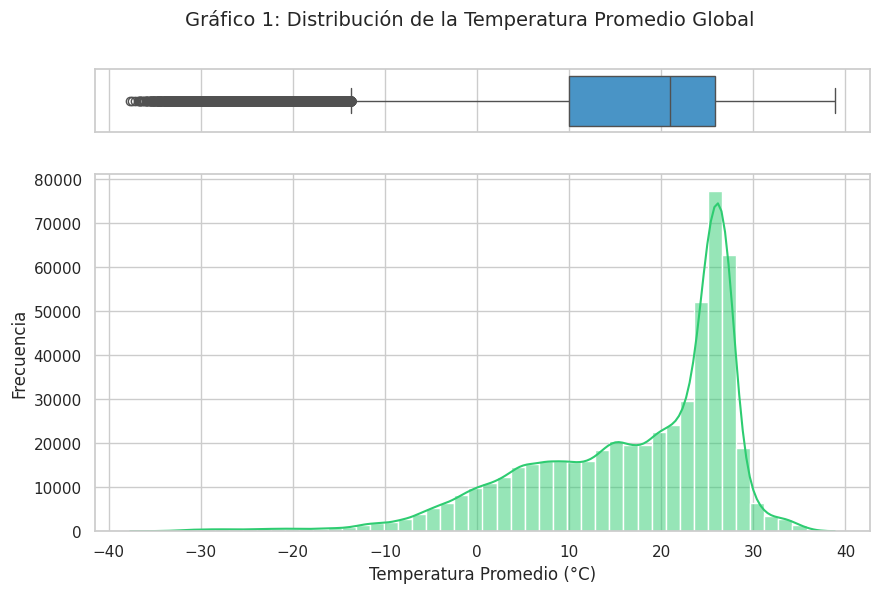

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_clean = df.dropna(subset=['AverageTemperature'])

# GRÁFICO 1: Distribución (Histograma + Boxplot)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

sns.boxplot(x=df_clean["AverageTemperature"], ax=ax_box, color="#3498db")
sns.histplot(df_clean, x="AverageTemperature", bins=50, kde=True, ax=ax_hist, color="#2ecc71")

ax_box.set(yticks=[])
ax_hist.set_xlabel("Temperatura Promedio (°C)")
ax_hist.set_ylabel("Frecuencia")
fig.suptitle("Gráfico 1: Distribución de la Temperatura Promedio Global", fontsize=14)
plt.show()

**Explicación Gráfico 1:** Este gráfico muestra visualmente cómo se distribuyen todas las temperaturas registradas. El histograma nos permite identificar dónde se concentra la mayor densidad de las temperaturas mundiales, mientras que el boxplot superior nos indica la mediana y nos confirma que las anomalías o valores extremos están delimitados lógicamente por los polos y desiertos.

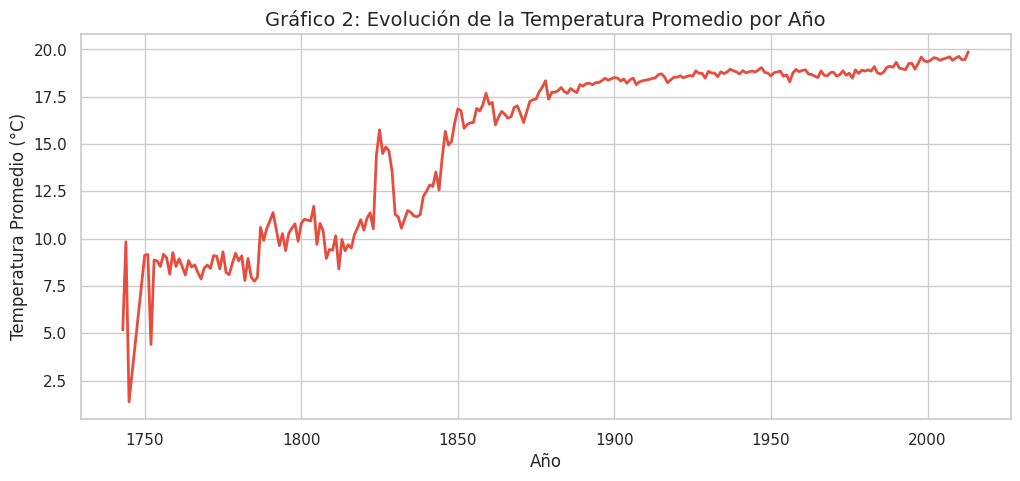

In [6]:
# GRÁFICO 2: Relación temporal
plt.figure(figsize=(12, 5))
tendencia_anual = df_clean.groupby('Year')['AverageTemperature'].mean().reset_index()
sns.lineplot(data=tendencia_anual, x='Year', y='AverageTemperature', color="#e74c3c", linewidth=2)

plt.title("Gráfico 2: Evolución de la Temperatura Promedio por Año", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Temperatura Promedio (°C)")
plt.show()

**Explicación Gráfico 2:** Esta gráfica temporal consolida la temperatura media anual a nivel mundial. Visualmente es evidente que en los primeros siglos del registro existe una inestabilidad alta en la curva (por la falta de estaciones meteorológicas globales). Sin embargo, al acercarnos a la época contemporánea (siglos XX y XXI), la curva muestra un claro patrón ascendente que valida empíricamente el fenómeno del calentamiento global.

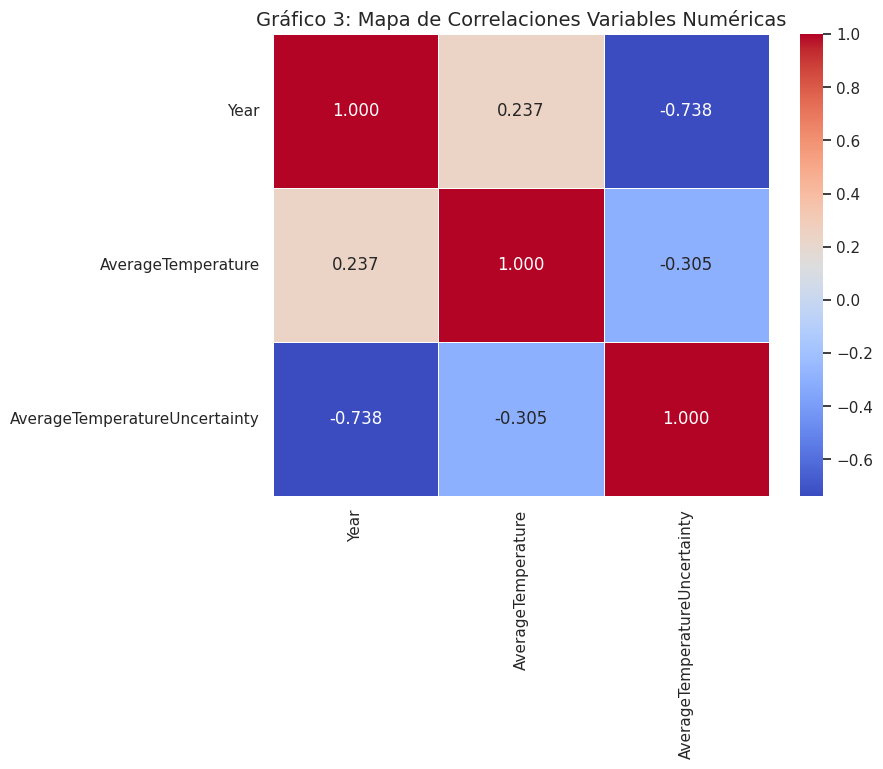

In [7]:
# GRÁFICO 3: Mapa de Correlaciones
plt.figure(figsize=(8, 6))
matriz_correlacion = df_clean[['Year', 'AverageTemperature', 'AverageTemperatureUncertainty']].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".3f", linewidths=.5)
plt.title("Gráfico 3: Mapa de Correlaciones Variables Numéricas", fontsize=14)
plt.show()

**Explicación Gráfico 3:** El mapa de calor nos muestra la fuerza de la relación lineal entre las variables numéricas clave. Lo más destacable aquí es observar la relación entre el avance del tiempo ('Year') y la incertidumbre de la medición ('AverageTemperatureUncertainty'). Se visualiza una correlación negativa, lo que lógicamente significa que a medida que la tecnología ha avanzado con los años, el margen de error meteorológico ha disminuido.